# CLIP: Matching Images and Text in a Shared Embedding Space

**CLIP** (*Contrastive Language–Image Pre-training*, Radford et al., 2021) is a model that learns a single vector space in which **images and text are directly comparable**. Once you have it, asking *"does this caption describe this image?"* becomes a dot product.

## Why CLIP is interesting

Most vision models output a fixed list of class labels they were trained on. CLIP outputs an **embedding** — a high-dimensional vector — and the matching label for an image is whichever piece of text *happens to land closest* in that vector space. That means **zero-shot classification**: you can describe new classes in natural language at inference time, no fine-tuning required.

## Architecture in one paragraph

CLIP has two encoders trained jointly:

- An **image encoder** (a Vision Transformer or ResNet) takes a pixel tensor and produces a vector $v_{\text{img}} \in \mathbb{R}^D$.
- A **text encoder** (a Transformer) takes a tokenized string and produces a vector $v_{\text{txt}} \in \mathbb{R}^D$ of the *same* dimensionality.

Both vectors are **L2-normalized**, so their dot product is the cosine similarity

$$\text{sim}(v_{\text{img}}, v_{\text{txt}}) = \frac{v_{\text{img}} \cdot v_{\text{txt}}}{\lVert v_{\text{img}} \rVert \, \lVert v_{\text{txt}} \rVert} \in [-1, 1].$$

## How it was trained

On ~400M (image, caption) pairs scraped from the web. For each minibatch of $N$ pairs, CLIP computes the $N \times N$ similarity matrix between every image and every caption. The loss pushes the **diagonal** (true pairs) up and the **off-diagonal** (mismatched pairs) down. This is the *contrastive* part.

Result: matching (image, text) pairs are pulled together in the embedding space, mismatched ones are pushed apart, and there's a single geometry where you can compare anything to anything.

## What this notebook shows

1. **Image ↔ text similarity matrix** — the picture you've seen in the CLIP paper.
2. **Zero-shot classification** — use captions as a class vocabulary.
3. **Text → image retrieval** — type a query, get the matching pictures.
4. **Embedding-space visualization** — project images and text down to 2D and watch matching pairs co-locate.

---

In [ ]:
# --- Colab bootstrap (no-op when running locally) ---
# When this notebook is opened in Google Colab, clone the repo so the
# `clip_demo` package is importable, install the one dependency Colab
# does not ship with, and enable widget rendering for the interactive
# retrieval cell. On a local Jupyter kernel this block is skipped.
import sys

if "google.colab" in sys.modules:
    import os
    if not os.path.exists("/content/emb"):
        !git clone -q https://github.com/mbednarski/emb.git /content/emb
    %cd /content/emb
    !pip install -q open-clip-torch
    from google.colab import output as _colab_output
    _colab_output.enable_custom_widget_manager()
    print("Colab bootstrap complete - using GPU runtime is strongly recommended.")


In [1]:
# Make the clip_demo package importable when running from notebooks/
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import torch

from clip_demo import (
    SUPPORTED_MODELS,
    draw_clip_diagram,
    encode_images,
    encode_texts,
    fetch_sample_images,
    load_images_from_folder,
    load_model,
    plot_embedding_2d,
    plot_similarity_matrix,
    plot_topk_retrieval,
    plot_zeroshot_predictions,
)
from clip_demo.data import labels_for_sample_paths
from clip_demo.model import count_parameters
from clip_demo.viz import plot_image_grid

print("Imports OK. Repo root:", ROOT)

Imports OK. Repo root: E:\code\pf2e\emb


### Diagram

Two encoders, one shared embedding space, one cosine similarity at the end.

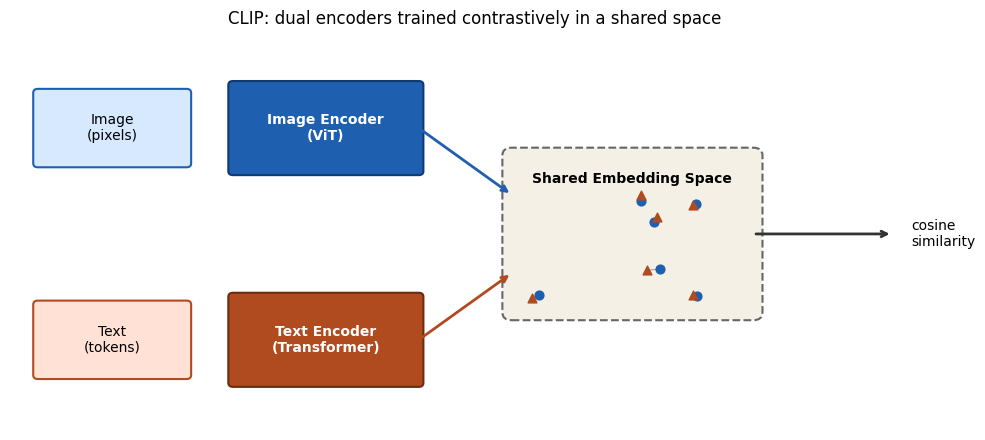

In [2]:
fig = draw_clip_diagram()
plt.show()

## Configuration

Pick a model. Smaller = faster; larger = sharper representations. The smallest (`ViT-B-32`) is plenty for a live demo on a consumer GPU.

In [3]:
# Supported (model_name, pretrained tag) combinations:
for name, tags in SUPPORTED_MODELS.items():
    print(f"  {name:10s} -> {tags}")

MODEL_NAME = "ViT-B-32"          # try: "ViT-B-16", "ViT-L-14"
PRETRAINED = "openai"            # try: "laion2b_s34b_b79k" (ViT-B-32)
DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"
IMAGE_DIR  = ROOT / "images"     # drop your own .jpg/.png here; empty -> auto-download samples
CACHE_DIR  = ROOT / "cache"

print(f"\nUsing {MODEL_NAME}/{PRETRAINED} on {DEVICE}")

  ViT-B-32   -> ['openai', 'laion2b_s34b_b79k']
  ViT-B-16   -> ['openai', 'laion2b_s34b_b88k']
  ViT-L-14   -> ['openai', 'laion2b_s32b_b82k']

Using ViT-B-32/openai on cuda


## Load the model

In [4]:
model, preprocess, tokenizer = load_model(MODEL_NAME, PRETRAINED, DEVICE)
n_params = count_parameters(model)
print(f"Loaded {MODEL_NAME}/{PRETRAINED}")
print(f"  parameters : {n_params/1e6:.1f}M")
print(f"  device     : {DEVICE}")
print(f"  embed dim  : {model.visual.output_dim}")

Loaded ViT-B-32/openai
  parameters : 151.3M
  device     : cuda
  embed dim  : 512


## Load images

If `IMAGE_DIR` (./images) contains any image files, those are used. Otherwise the notebook downloads a small set of diverse public-domain samples from Wikimedia Commons into `./cache/`.

E:\code\pf2e\emb\images is empty - fetching bundled sample images into E:\code\pf2e\emb\cache

10 images:
  - golden_retriever.jpg
  - tabby_cat.jpg
  - sports_car.jpg
  - pizza.jpg
  - mountain.jpg
  - beach.jpg
  - coffee.jpg
  - eiffel_tower.jpg
  - apple.jpg
  - books.jpg


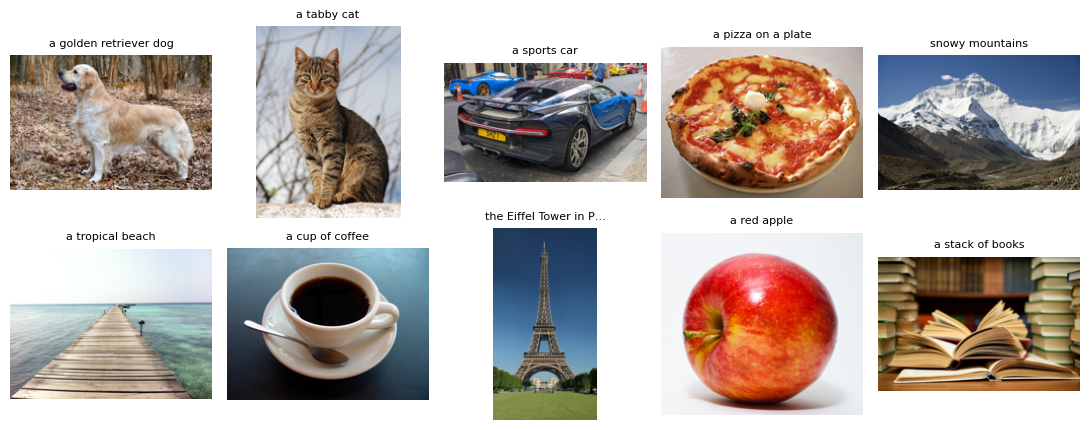

In [5]:
user_images = load_images_from_folder(IMAGE_DIR)
if user_images:
    print(f"Using {len(user_images)} image(s) from {IMAGE_DIR}")
    image_paths = user_images
else:
    print(f"{IMAGE_DIR} is empty - fetching bundled sample images into {CACHE_DIR}")
    image_paths = fetch_sample_images(CACHE_DIR)

print(f"\n{len(image_paths)} images:")
for p in image_paths:
    print("  -", p.name)

image_short_labels = labels_for_sample_paths(image_paths)
fig = plot_image_grid(image_paths, image_short_labels)
plt.show()

## Encode everything once

We encode every image once, then re-use the embeddings across all four demos.

In [6]:
img_emb = encode_images(model, preprocess, image_paths, DEVICE)
print(f"Image embeddings: shape={tuple(img_emb.shape)}, dtype={img_emb.dtype}")
print(f"L2 norms (should be ~1): min={img_emb.norm(dim=-1).min().item():.4f}, "
      f"max={img_emb.norm(dim=-1).max().item():.4f}")

Image embeddings: shape=(10, 512), dtype=torch.float32
L2 norms (should be ~1): min=1.0000, max=1.0000


## Demo 1 — Image ↔ text similarity matrix

We write a natural-language **caption** for each image and feed both images and captions through their respective encoders. The resulting $N \times M$ matrix is cosine similarity — the *signature* CLIP visualization.

**How to read it:** if the model "works," the diagonal (image $i$ vs. caption $i$) should clearly dominate row-wise and column-wise.

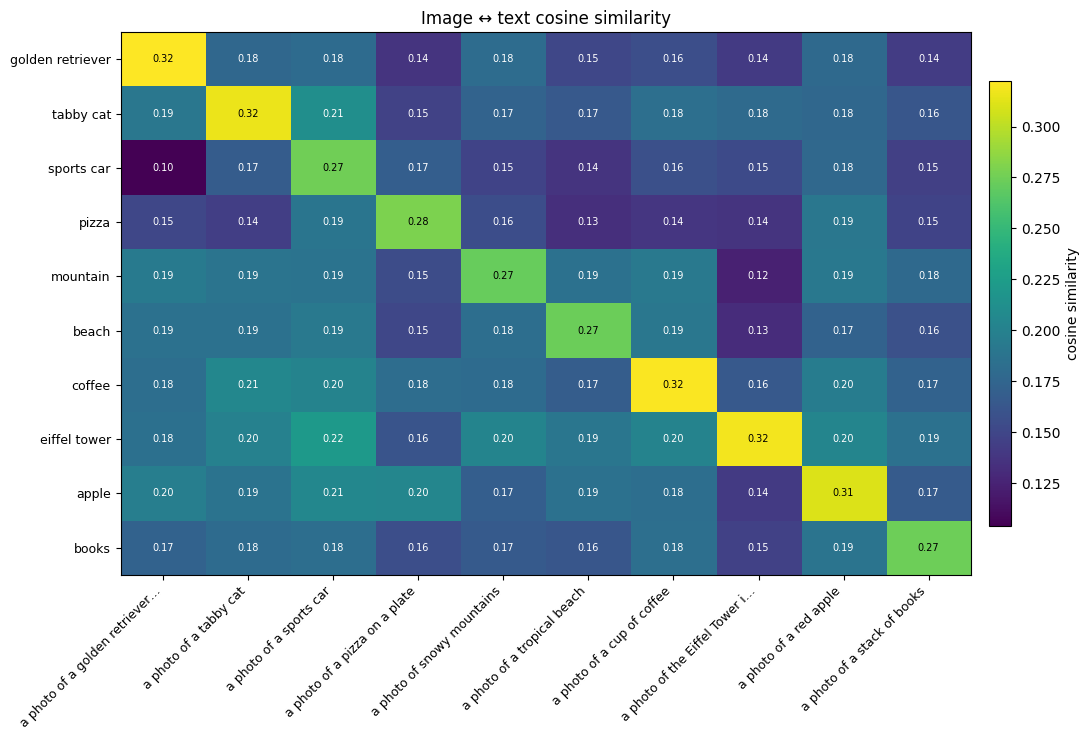

In [7]:
captions = [f"a photo of {lbl}" for lbl in image_short_labels]
txt_emb = encode_texts(model, tokenizer, captions, DEVICE)

fig = plot_similarity_matrix(img_emb, txt_emb, image_paths, captions)
plt.show()

### Same numbers, viewed as probabilities

If we treat each row as logits (multiplied by CLIP's learned temperature, ~100) and softmax, we get the probability the model assigns to each caption being *the* match for that image.

In [8]:
logits = 100.0 * img_emb @ txt_emb.T
probs = logits.softmax(dim=-1).detach().cpu().float().numpy()

print(f"{'image':<24} -> top match (prob)")
print("-" * 60)
for i, p in enumerate(image_paths):
    top = int(np.argmax(probs[i]))
    print(f"{p.stem:<24} -> {captions[top][:36]:<36} ({probs[i, top]:.3f})")

image                    -> top match (prob)
------------------------------------------------------------
golden_retriever         -> a photo of a golden retriever dog    (1.000)
tabby_cat                -> a photo of a tabby cat               (1.000)
sports_car               -> a photo of a sports car              (1.000)
pizza                    -> a photo of a pizza on a plate        (1.000)
mountain                 -> a photo of snowy mountains           (0.998)
beach                    -> a photo of a tropical beach          (0.999)
coffee                   -> a photo of a cup of coffee           (1.000)
eiffel_tower             -> a photo of the Eiffel Tower in Paris (1.000)
apple                    -> a photo of a red apple               (1.000)
books                    -> a photo of a stack of books          (0.999)


## Demo 2 — Zero-shot classification

Same idea, but instead of one caption per image we define a **shared label vocabulary** and ask CLIP to pick the most likely label for each picture. No training, no labelled data: just text.

The prompt template `"a photo of a {label}"` consistently outperforms raw labels — it nudges the text into the same distribution as the captions CLIP was trained on.

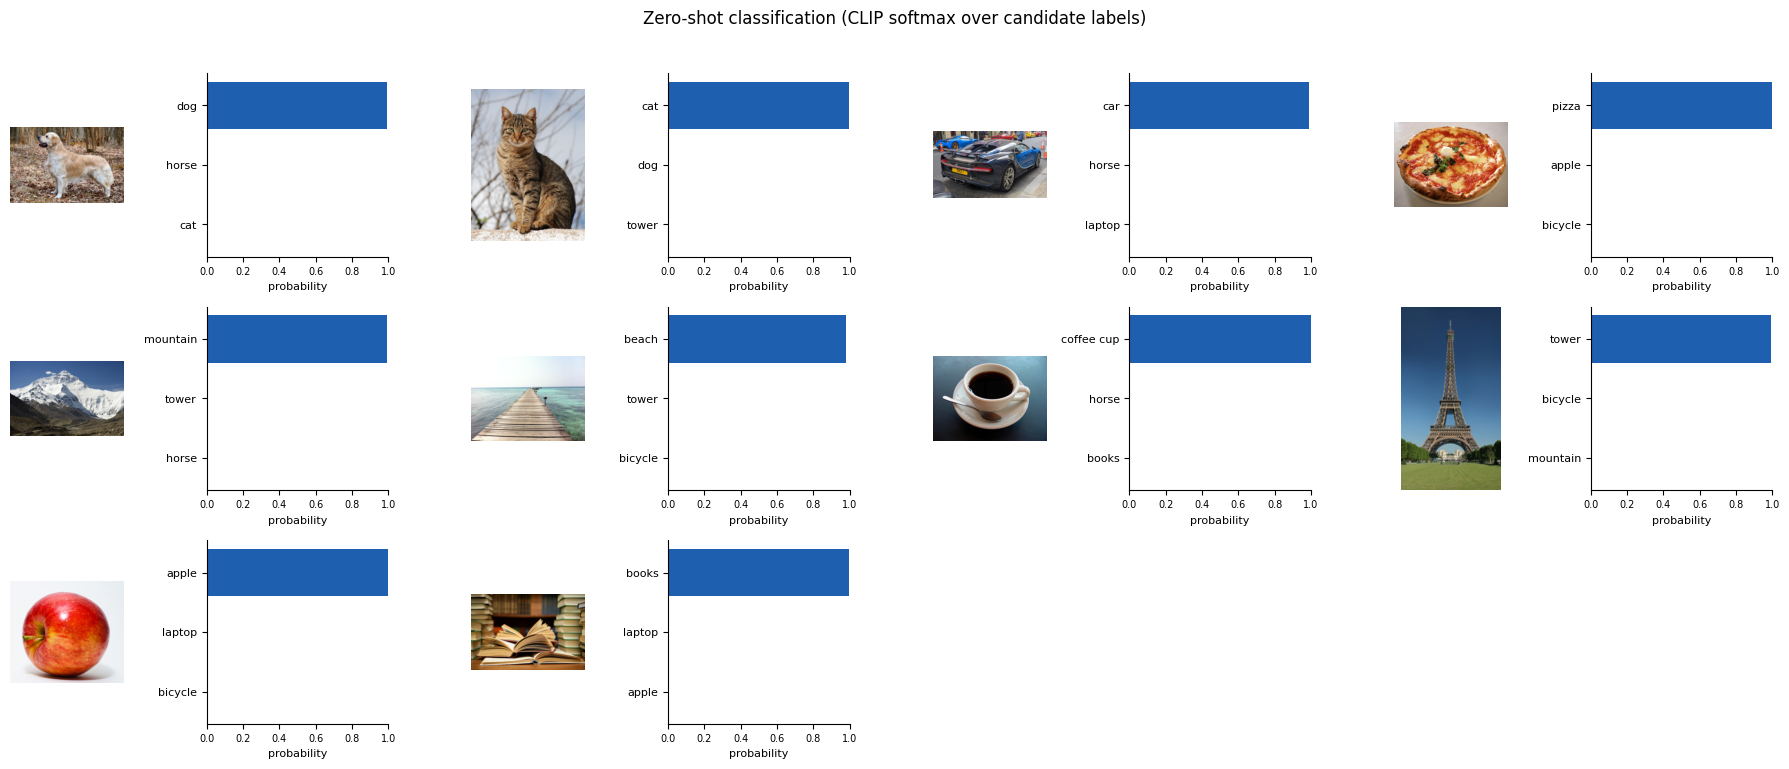

In [9]:
CLASS_LABELS = [
    "dog", "cat", "car", "pizza", "mountain",
    "beach", "coffee cup", "tower", "apple", "books",
    "airplane", "bicycle", "laptop", "horse",
]
label_prompts = [f"a photo of a {c}" for c in CLASS_LABELS]
label_emb = encode_texts(model, tokenizer, label_prompts, DEVICE)

fig = plot_zeroshot_predictions(img_emb, label_emb, image_paths, CLASS_LABELS, top_k=3)
plt.show()

## Demo 3 — Text → image retrieval

Flipping the problem: given a free-form text query, which images in our collection are the closest match in CLIP space? This is the embedding-side of how systems like Google Image search by description or Apple Photos' "search for sunset" work.

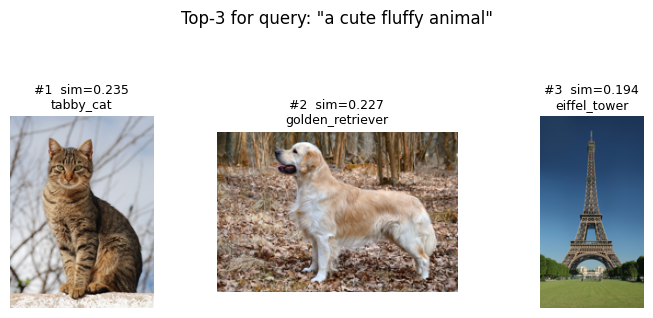

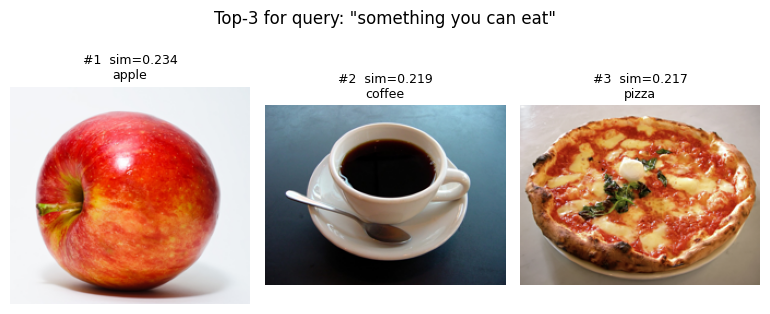

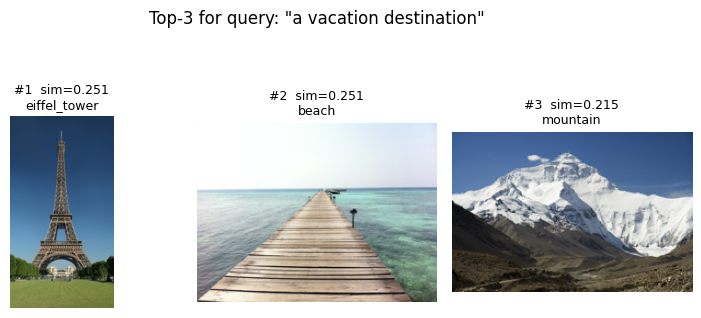

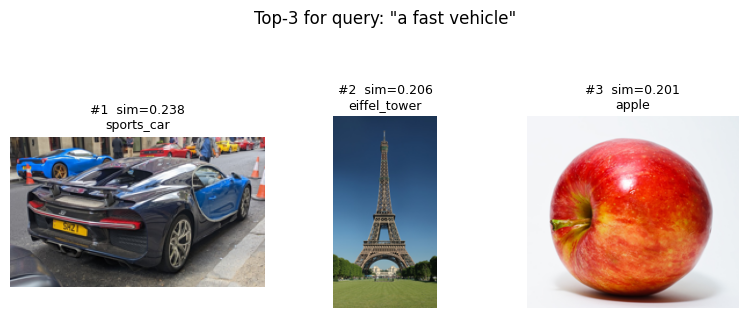

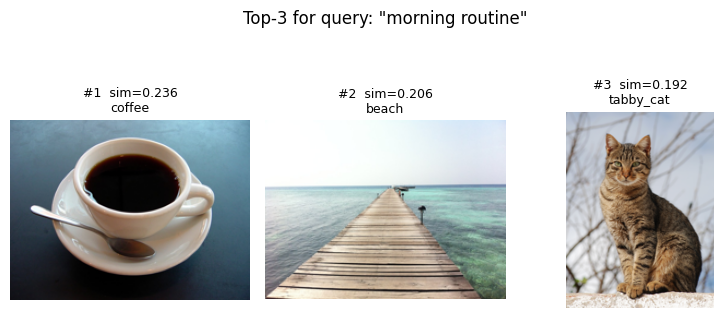

In [10]:
QUERIES = [
    "a cute fluffy animal",
    "something you can eat",
    "a vacation destination",
    "a fast vehicle",
    "morning routine",
]

for query in QUERIES:
    q_emb = encode_texts(model, tokenizer, [query], DEVICE)
    fig = plot_topk_retrieval(query, q_emb, img_emb, image_paths, k=3)
    plt.show()

### Interactive retrieval (optional)

Type a query in the textbox below and hit *Enter* to retrieve the top-3 matching images. Requires `ipywidgets` (already in this project's dependencies).

In [11]:
import ipywidgets as widgets
from IPython.display import clear_output, display

query_box = widgets.Text(
    value="a colorful object outdoors",
    placeholder="type a query, then press Search",
    description="Query:",
    layout=widgets.Layout(width="60%"),
)
search_btn = widgets.Button(description="Search", button_style="primary")
output = widgets.Output()

def _run_query(_=None):
    with output:
        clear_output(wait=True)
        text = query_box.value.strip()
        if not text:
            print("(empty query)")
            return
        q_emb = encode_texts(model, tokenizer, [text], DEVICE)
        fig = plot_topk_retrieval(text, q_emb, img_emb, image_paths, k=3)
        plt.show()

search_btn.on_click(_run_query)
display(widgets.HBox([query_box, search_btn]), output)
_run_query()


Output()

## Demo 4 — The shared embedding space, visualized

Image and text vectors live in the *same* high-dimensional space. We can't see hundreds of dimensions, but a PCA projection to 2D is enough to see that **each image lands near its matching caption** — the geometric punchline of contrastive training.

Image embeddings are blue circles; text embeddings are orange triangles. Thin gray lines connect matching (image, caption) pairs.

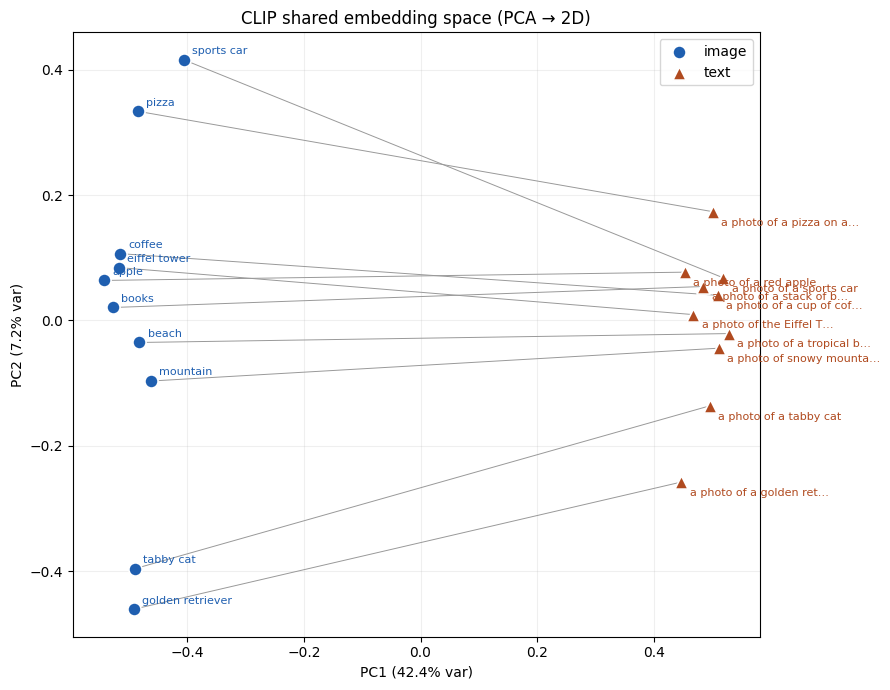

In [12]:
fig = plot_embedding_2d(
    img_emb, txt_emb,
    image_labels=[p.stem.replace("_", " ") for p in image_paths],
    text_labels=captions,
)
plt.show()

## Wrap-up

We've seen the four canonical ways to use CLIP:

1. Score image–text pairs with a **cosine similarity matrix**.
2. Use a list of label prompts for **zero-shot classification**.
3. Use a text query to **retrieve images**.
4. **Visualize the shared embedding space** to see why all of this works at all.

### Things to try next

- Drop your own images into `./images/` and re-run the notebook. CLIP is surprisingly good at *anything you can describe in English*.
- Switch `MODEL_NAME` to `ViT-L-14` and rerun. The larger model is sharper on fine-grained categories.
- Try the LAION-trained checkpoint (`pretrained="laion2b_s34b_b79k"` for `ViT-B-32`) and compare — different training data, different biases.
- Experiment with **prompt engineering**: `"a photo of a {x}"` vs. `"a blurry photo of a {x}"` vs. `"a sketch of a {x}"` will surface very different similarities.
- For zero-shot classification, build an ensemble of prompt templates per class and average their text embeddings — a well-known free accuracy boost.